In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load listings
listings = pd.read_csv('listings.csv')
print("LISTINGS DATA:")
print(f"Shape: {listings.shape}")
print(f"Columns: {listings.columns.tolist()}")
print()

# Load reviews
reviews = pd.read_csv('reviews.csv')
print("REVIEWS DATA:")
print(f"Shape: {reviews.shape}")
print(f"Columns: {reviews.columns.tolist()}")
print()

# Load calendar
calendar = pd.read_csv('calendar.csv')
print("CALENDAR DATA:")
print(f"Shape: {calendar.shape}")
print(f"Columns: {calendar.columns.tolist()}")


LISTINGS DATA:
Shape: (3818, 92)
Columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space', 'description', 'experiences_offered', 'neighborhood_overview', 'notes', 'transit', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet', 'price', 'weekly_price', 'monthly_price',

In [2]:
# ============================================================================
# CELL 1: MERGE ALL DATA FILES
# ============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Merging data files...")

# Aggregate reviews by listing_id
reviews_agg = reviews.groupby('listing_id').agg({
    'id': 'count',  # number of reviews
    'comments': lambda x: ' '.join(x.fillna('')),  # combine all review text
    'date': 'max'  # last review date
}).reset_index()

reviews_agg.columns = ['id', 'total_reviews_count', 'all_reviews_text', 'last_review_date']

# Merge reviews with listings
df = listings.merge(reviews_agg, on='id', how='left')
df['total_reviews_count'] = df['total_reviews_count'].fillna(0)
df['all_reviews_text'] = df['all_reviews_text'].fillna('')

print(f"After merging reviews: {df.shape}")

# Aggregate calendar by listing_id (occupancy stats)
calendar['date'] = pd.to_datetime(calendar['date'])
calendar['available'] = (calendar['available'] == 't').astype(int)

calendar_agg = calendar.groupby('listing_id').agg({
    'available': ['sum', 'mean'],  # total available days, occupancy rate
    'date': ['min', 'max']  # date range
}).reset_index()

calendar_agg.columns = ['id', 'available_days', 'occupancy_rate', 'calendar_start', 'calendar_end']

# Merge calendar with df
df = df.merge(calendar_agg, on='id', how='left')
df['occupancy_rate'] = df['occupancy_rate'].fillna(df['occupancy_rate'].median())

print(f"After merging calendar: {df.shape}")
print(f"✓ All data merged successfully")
print()
print(f"Columns available: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")

Merging data files...
After merging reviews: (3818, 95)
After merging calendar: (3818, 99)
✓ All data merged successfully

Columns available: 99
Rows: 3818


In [3]:
# Check all null values without truncation
pd.set_option('display.max_rows', None)
print(df.isnull().sum())

id                                     0
listing_url                            0
scrape_id                              0
last_scraped                           0
name                                   0
summary                              177
space                                569
description                            0
experiences_offered                    0
neighborhood_overview               1032
notes                               1606
transit                              934
thumbnail_url                        320
medium_url                           320
picture_url                            0
xl_picture_url                       320
host_id                                0
host_url                               0
host_name                              2
host_since                             2
host_location                          8
host_about                           859
host_response_time                   523
host_response_rate                   523
host_acceptance_

In [4]:
print(df.dtypes)

id                                           int64
listing_url                                 object
scrape_id                                    int64
last_scraped                                object
name                                        object
summary                                     object
space                                       object
description                                 object
experiences_offered                         object
neighborhood_overview                       object
notes                                       object
transit                                     object
thumbnail_url                               object
medium_url                                  object
picture_url                                 object
xl_picture_url                              object
host_id                                      int64
host_url                                    object
host_name                                   object
host_since                     

In [5]:
# Price conversions - convert to string first
df['price'] = df['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
df['cleaning_fee'] = df['cleaning_fee'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

# Percentage conversions - convert to string first
df['host_response_rate'] = df['host_response_rate'].astype(str).str.replace('%', '').astype(float)
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(str).str.replace('%', '').astype(float)

# Extra people to float
df['extra_people'] = pd.to_numeric(df['extra_people'], errors='coerce')

# Room counts to int
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce').fillna(0).astype(int)
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce').fillna(0).astype(int)
df['beds'] = pd.to_numeric(df['beds'], errors='coerce').fillna(0).astype(int)
df['accommodates'] = pd.to_numeric(df['accommodates'], errors='coerce').astype(int)

# Boolean to int
bool_cols = ['host_is_superhost', 'has_availability', 'instant_bookable', 'require_guest_profile_picture', 'require_guest_phone_verification', 'is_location_exact', 'requires_license', 'host_has_profile_pic', 'host_identity_verified']
for col in bool_cols:
    df[col] = (df[col] == 't').astype(int)

# Dates to datetime
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Review scores to float
review_cols = ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']
for col in review_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("fixed")

fixed


In [6]:
# Delete columns
df = df.drop(columns=['license', 'square_feet', 'security_deposit', 'weekly_price', 'monthly_price', 'notes', 'neighborhood_overview', 'transit', 'host_about'])

# Impute with 0
df['cleaning_fee'] = df['cleaning_fee'].fillna(0)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Impute with median
numeric_cols = ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'host_response_rate', 'host_acceptance_rate', 'bathrooms', 'bedrooms', 'beds']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill remaining with 0
df = df.fillna(0)

print(f"Cleaned: {df.shape}")

Cleaned: (3818, 90)


In [7]:
# Check unique values per column
unique_counts = df.nunique()
constant_cols = unique_counts[unique_counts == 1].index.tolist()

print("Columns with only 1 unique value (useless):")
print(constant_cols)
print()
print(f"Total: {len(constant_cols)} columns")
df = df.drop(columns=['scrape_id', 'last_scraped', 'experiences_offered', 'market', 'country_code', 'country', 'extra_people', 'has_availability', 'calendar_last_scraped', 'requires_license', 'jurisdiction_names', 'calendar_start', 'calendar_end'])

print(f"✓ Dropped 13 constant columns")
print(f"Remaining: {df.shape[1]} columns, {df.shape[0]} rows")

Columns with only 1 unique value (useless):
['scrape_id', 'last_scraped', 'experiences_offered', 'market', 'country_code', 'country', 'extra_people', 'has_availability', 'calendar_last_scraped', 'requires_license', 'jurisdiction_names', 'calendar_start', 'calendar_end']

Total: 13 columns
✓ Dropped 13 constant columns
Remaining: 77 columns, 3818 rows


In [8]:
print("STREET - Unique values:")
print(df['street'].nunique())
print(df['street'].value_counts().head(10))
print()

print("CITY - Unique values:")
print(df['city'].nunique())
print(df['city'].value_counts().head(10))

STREET - Unique values:
1442
street
1st Avenue, Seattle, WA 98101, United States                 30
12th Avenue East, Seattle, WA 98102, United States           29
Hubbell Place, Seattle, WA 98101, United States              29
East Denny Way, Seattle, WA 98122, United States             28
10th Avenue East, Seattle, WA 98102, United States           28
1st Avenue, Seattle, WA 98121, United States                 25
Boylston Avenue East, Seattle, WA 98102, United States       22
Queen Anne Avenue North, Seattle, WA 98109, United States    22
Summit Avenue East, Seattle, WA 98102, United States         21
2nd Avenue, Seattle, WA 98121, United States                 20
Name: count, dtype: int64

CITY - Unique values:
7
city
Seattle                  3810
West Seattle                2
Seattle                     2
Ballard, Seattle            1
西雅图                         1
Phinney Ridge Seattle       1
seattle                     1
Name: count, dtype: int64


In [9]:
drop_cols = ['id', 'listing_url', 'host_id', 'host_url', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_thumbnail_url', 'host_picture_url', 'host_name', 'host_location', 'host_response_time', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'zipcode', 'smart_location', 'is_location_exact', 'first_review', 'cancellation_policy', 'calculated_host_listings_count', 'summary', 'name', 'availability_60', 'availability_90']

df = df.drop(columns=drop_cols, errors='ignore')
print(f"✓ Dropped columns")
print(f"Final: {df.shape[1]} columns, {df.shape[0]} rows")

✓ Dropped columns
Final: 51 columns, 3818 rows


In [10]:
print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['space', 'description', 'host_since', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 'state', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'price', 'cleaning_fee', 'guests_included', 'minimum_nights', 'maximum_nights', 'calendar_updated', 'availability_30', 'availability_365', 'number_of_reviews', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'require_guest_profile_picture', 'require_guest_phone_verification', 'reviews_per_month', 'total_reviews_count', 'all_reviews_text', 'last_review_date', 'available_days', 'occupancy_rate']


In [11]:
df = df[df['property_type'] != '0']

small_types = ['Loft', 'Bed & Breakfast', 'Cabin']
df['property_type'] = df['property_type'].replace(small_types, 'Other')
df = df[df['property_type'] != 0].reset_index(drop=True)

print(df['property_type'].value_counts())
print(f"Total rows: {len(df)}")

property_type
House          1733
Apartment      1708
Other           120
Townhouse       118
Condominium      91
Camper/RV        13
Bungalow         13
Boat              8
Tent              5
Treehouse         3
Dorm              2
Chalet            2
Yurt              1
Name: count, dtype: int64
Total rows: 3817


In [12]:
# Save cleaned data for Tableau  
# ← place this AFTER df = df[df['price'] <= 400]
df.to_csv('cleaned_listings.csv', index=False)
print(f"✓ Saved cleaned_listings.csv — {df.shape[0]} rows, {df.shape[1]} columns")

✓ Saved cleaned_listings.csv — 3817 rows, 51 columns


In [13]:
#======================================================================
#EDA
#======================================================================
print("="*70)
print("EDA")
print("="*70)

EDA


In [14]:
df = df[df['price'] <= 400].reset_index(drop=True)

print(f" Removed properties with price > $600")
print(f"Final dataset: {len(df)} rows")
print(f"Price range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")
print(df['price'].describe())

 Removed properties with price > $600
Final dataset: 3754 rows
Price range: $20.00 - $400.00
count    3754.000000
mean      120.750133
std        68.753838
min        20.000000
25%        75.000000
50%       100.000000
75%       150.000000
max       400.000000
Name: price, dtype: float64


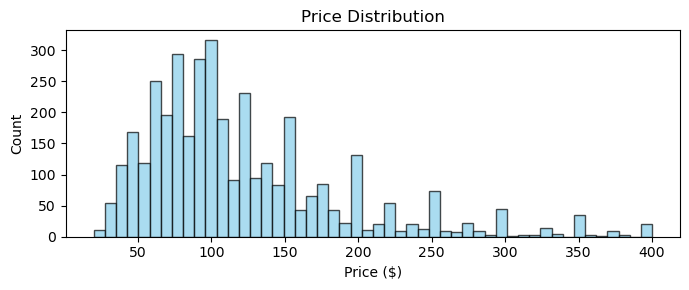

Total rows: 3754
Price range: $20.00 - $400.00
count    3754.000000
mean      120.750133
std        68.753838
min        20.000000
25%        75.000000
50%       100.000000
75%       150.000000
max       400.000000
Name: price, dtype: float64


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))
plt.hist(df['price'], bins=50, edgecolor='black', color='skyblue', alpha=0.7)
plt.title('Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=100)
plt.show()

print(f"Total rows: {len(df)}")
print(f"Price range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")
print(df['price'].describe())

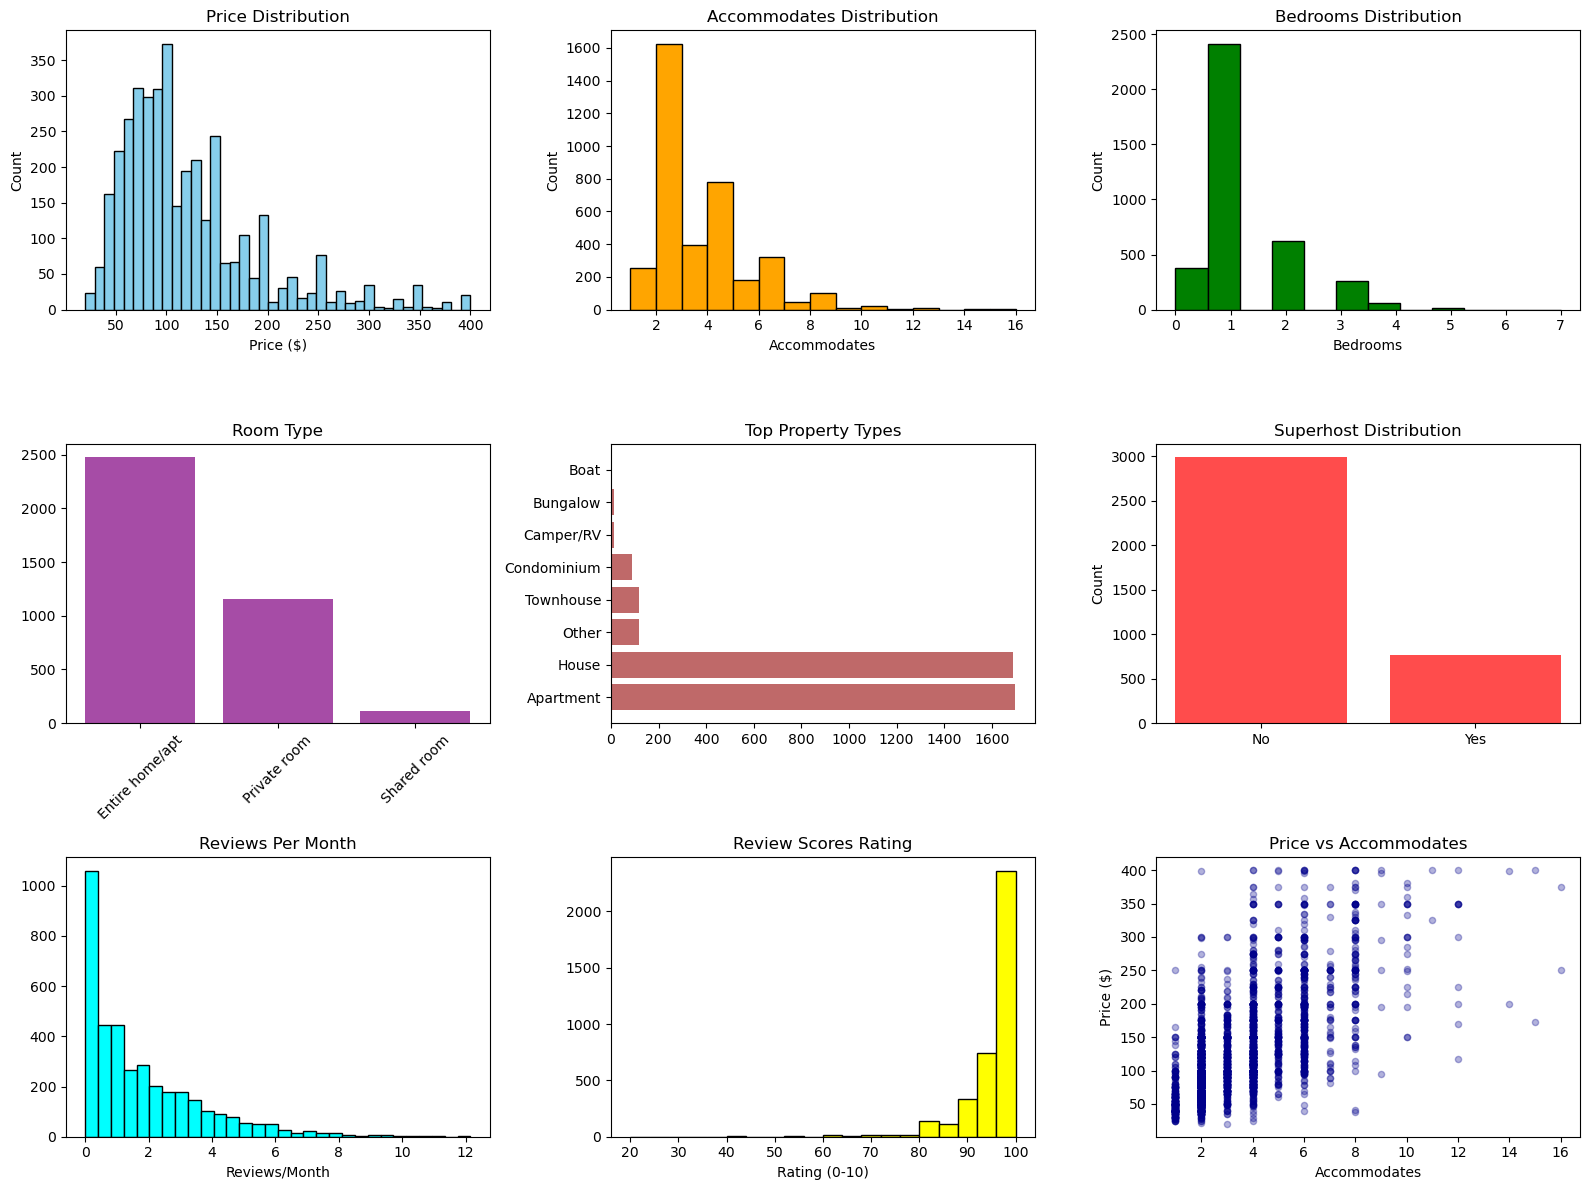

EDA graphs generated


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# 1. Price distribution
axes[0, 0].hist(df['price'], bins=40, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Count')

# 2. Accommodates
axes[0, 1].hist(df['accommodates'], bins=15, edgecolor='black', color='orange')
axes[0, 1].set_title('Accommodates Distribution')
axes[0, 1].set_xlabel('Accommodates')
axes[0, 1].set_ylabel('Count')

# 3. Bedrooms
axes[0, 2].hist(df['bedrooms'], bins=12, edgecolor='black', color='green')
axes[0, 2].set_title('Bedrooms Distribution')
axes[0, 2].set_xlabel('Bedrooms')
axes[0, 2].set_ylabel('Count')

# 4. Room type
room_counts = df['room_type'].value_counts()
axes[1, 0].bar(room_counts.index, room_counts.values, color='purple', alpha=0.7)
axes[1, 0].set_title('Room Type')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Property type
prop_counts = df['property_type'].value_counts().head(8)
axes[1, 1].barh(prop_counts.index, prop_counts.values, color='brown', alpha=0.7)
axes[1, 1].set_title('Top Property Types')

# 6. Host is superhost
superhost_counts = df['host_is_superhost'].value_counts()
axes[1, 2].bar(['No', 'Yes'], [superhost_counts[0], superhost_counts[1]], color='red', alpha=0.7)
axes[1, 2].set_title('Superhost Distribution')
axes[1, 2].set_ylabel('Count')

# 7. Reviews per month
axes[2, 0].hist(df['reviews_per_month'], bins=30, edgecolor='black', color='cyan')
axes[2, 0].set_title('Reviews Per Month')
axes[2, 0].set_xlabel('Reviews/Month')

# 8. Review rating
axes[2, 1].hist(df['review_scores_rating'], bins=20, edgecolor='black', color='yellow')
axes[2, 1].set_title('Review Scores Rating')
axes[2, 1].set_xlabel('Rating (0-10)')

# 9. Price vs Accommodates (scatter)
axes[2, 2].scatter(df['accommodates'], df['price'], alpha=0.3, s=20, color='darkblue')
axes[2, 2].set_title('Price vs Accommodates')
axes[2, 2].set_xlabel('Accommodates')
axes[2, 2].set_ylabel('Price ($)')

plt.tight_layout()
plt.savefig('eda_full.png', dpi=100, bbox_inches='tight')
plt.show()

print("EDA graphs generated")

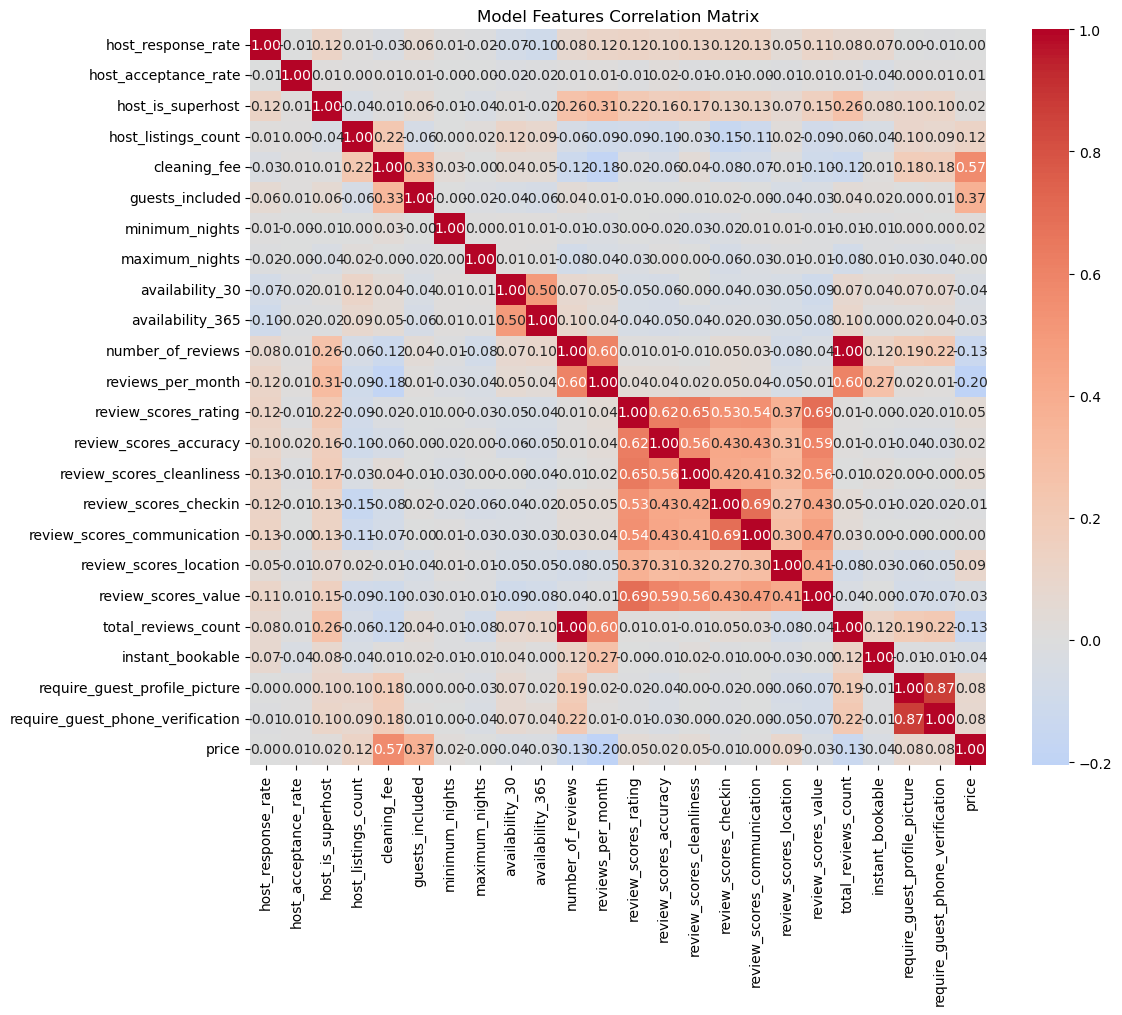

Top correlations with PRICE:
price                               1.000000
cleaning_fee                        0.571745
guests_included                     0.371145
host_listings_count                 0.124983
review_scores_location              0.088219
require_guest_profile_picture       0.079912
require_guest_phone_verification    0.077602
review_scores_rating                0.048834
review_scores_cleanliness           0.045644
minimum_nights                      0.021409
host_is_superhost                   0.019725
review_scores_accuracy              0.017895
host_acceptance_rate                0.006114
review_scores_communication         0.004274
host_response_rate                  0.000182
maximum_nights                     -0.003623
review_scores_checkin              -0.011370
availability_365                   -0.027846
review_scores_value                -0.034368
availability_30                    -0.035442
instant_bookable                   -0.038786
number_of_reviews         

In [17]:
model_features = ['host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 
                  'cleaning_fee', 'guests_included', 'minimum_nights', 'maximum_nights',
                  'availability_30', 'availability_365', 'number_of_reviews', 'reviews_per_month',
                  'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
                  'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
                  'review_scores_value', 'total_reviews_count', 'instant_bookable',
                  'require_guest_profile_picture', 'require_guest_phone_verification', 'price']

model_corr = df[model_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(model_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Model Features Correlation Matrix')
plt.tight_layout()
plt.savefig('model_correlation.png', dpi=100)
plt.show()

print("Top correlations with PRICE:")
price_corr = model_corr['price'].sort_values(ascending=False)
print(price_corr)

In [18]:
#======================================================================
#FEATURE ENGINEERING START
#======================================================================
print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

FEATURE ENGINEERING


In [19]:
from textblob import TextBlob
import json

print("Categorical Encoding...")

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['property_type', 'room_type', 'bed_type'], drop_first=True)

print(f"Categorical features encoded")
print(f"New columns: {df.shape[1]}")

Categorical Encoding...
Categorical features encoded
New columns: 66


In [20]:
print("Text Feature Engineering...")

# Description features
df['desc_length'] = df['description'].str.len()
df['desc_word_count'] = df['description'].str.split().str.len()
df['desc_sentiment'] = df['description'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Space features
df['space_length'] = df['space'].str.len()
df['space_word_count'] = df['space'].str.split().str.len()

print(f"✓ Text features created")
print(f"Total columns: {df.shape[1]}")

Text Feature Engineering...
✓ Text features created
Total columns: 71


In [21]:
print("Interaction Features...")

df['host_since'] = pd.to_datetime(df['host_since'])

df['price_per_guest'] = df['price'] / (df['guests_included'] + 1)
df['price_per_bed'] = df['price'] / (df['beds'] + 1)

df['host_days_active'] = (pd.Timestamp.now() - df['host_since']).dt.days

df['superhost_listings'] = df['host_is_superhost'] * df['host_listings_count']

print(f"✓ Interaction features created")
print(f"Total columns: {df.shape[1]}")

Interaction Features...
✓ Interaction features created
Total columns: 75


In [22]:
print("NaN count per column:")
nan_summary = df.isnull().sum()
print(nan_summary[nan_summary > 0])
if len(nan_summary[nan_summary > 0]) == 0:
    print("No NaN values remaining")
df = df.fillna(0)

print("Checking NaN values after full fill...")
nan_count = df.isnull().sum()
nan_cols = nan_count[nan_count > 0]
if len(nan_cols) > 0:
    print("Columns with NaN:")
    print(nan_cols)
else:
    print("✓ No NaN values found")
    
print(f"Total columns: {df.shape[1]}")

df['description'] = df['description'].fillna('').astype(str)
df['space'] = df['space'].fillna('').astype(str)

print("NLP Features: Enhanced Sentence Embeddings...")
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# Combine description + space for richer signal
combined_text = df['description'] + ' ' + df['space']

# Stronger embedding model
model = SentenceTransformer('all-mpnet-base-v2')
print("Encoding combined text...")
embeddings = model.encode(combined_text.values, show_progress_bar=True)

# More PCA components
pca = PCA(n_components=15)
embeddings_reduced = pca.fit_transform(embeddings)

for i in range(15):
    df[f'embed_pc{i}'] = embeddings_reduced[:, i]

print(f"✓ Enhanced embeddings created (15 PCA components)")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Total columns: {df.shape[1]}")

NaN count per column:
space_length        564
space_word_count    564
dtype: int64
Checking NaN values after full fill...
✓ No NaN values found
Total columns: 75
NLP Features: Enhanced Sentence Embeddings...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding combined text...


Batches:   0%|          | 0/118 [00:00<?, ?it/s]

✓ Enhanced embeddings created (15 PCA components)
Variance explained: 48.30%
Total columns: 90


In [23]:
import joblib

# Save PCA model (add right after pca.fit_transform)
joblib.dump(pca, 'airbnb_pca.pkl')

# Save median values used for imputation
median_values = {
    'review_scores_rating': df['review_scores_rating'].median(),
    'review_scores_accuracy': df['review_scores_accuracy'].median(),
    'review_scores_cleanliness': df['review_scores_cleanliness'].median(),
    'review_scores_checkin': df['review_scores_checkin'].median(),
    'review_scores_communication': df['review_scores_communication'].median(),
    'review_scores_location': df['review_scores_location'].median(),
    'review_scores_value': df['review_scores_value'].median(),
    'host_response_rate': df['host_response_rate'].median(),
    'host_acceptance_rate': df['host_acceptance_rate'].median(),
    'bathrooms': df['bathrooms'].median(),
    'bedrooms': df['bedrooms'].median(),
    'beds': df['beds'].median(),
}
joblib.dump(median_values, 'airbnb_medians.pkl')
print("✓ PCA and medians saved")

✓ PCA and medians saved


In [24]:
import joblib

joblib.dump(pca, 'airbnb_pca.pkl')          

median_values = { ... }                

joblib.dump(median_values, 'airbnb_medians.pkl')  
print("✓ PCA and medians saved")

✓ PCA and medians saved


In [25]:
print("Engineering location features...")

# Distance from Seattle center (47.6062, -122.3321)
seattle_lat, seattle_lng = 47.6062, -122.3321
df['distance_from_center'] = np.sqrt(
    (df['latitude'] - seattle_lat)**2 + 
    (df['longitude'] - seattle_lng)**2
)

# Location zones (neighborhood clusters)
df['lat_zone'] = pd.cut(df['latitude'], bins=5, labels=False)
df['lng_zone'] = pd.cut(df['longitude'], bins=5, labels=False)

# Waterfront proximity (rough)
df['near_water'] = (df['latitude'] > 47.65).astype(int)

# Location × property type interaction
df['location_quality'] = df['distance_from_center'] * df['bedrooms']

# Add to model_features
new_location_features = ['distance_from_center', 'lat_zone', 'lng_zone', 'near_water', 'location_quality']
model_features = model_features + new_location_features

print(f"✓ Location features added")
print(f"Total features: {len(model_features)}")

Engineering location features...
✓ Location features added
Total features: 29


In [26]:
print("="*70)
print("FEATURE ENGINEERING: Interaction Features")
print("="*70)
print()

# Host credibility from track record
df['host_credibility'] = df['host_response_rate'] * df['host_acceptance_rate']

# Superhost × experience
df['superhost_experience'] = df['host_is_superhost'] * df['host_days_active']

# Property quality × pricing power
df['property_quality'] = df['bedrooms'] * df['cleaning_fee']

print("✓ Interaction features created:")
print("  1. host_credibility (response_rate × acceptance_rate)")
print("  2. superhost_experience (superhost × days_active)")
print("  3. property_quality (bedrooms × cleaning_fee)")
print()

# Add to model features
interaction_features = ['host_credibility', 'superhost_experience', 'property_quality']
model_features = model_features + interaction_features

print(f"Total model features: {len(model_features)}")

FEATURE ENGINEERING: Interaction Features

✓ Interaction features created:
  1. host_credibility (response_rate × acceptance_rate)
  2. superhost_experience (superhost × days_active)
  3. property_quality (bedrooms × cleaning_fee)

Total model features: 32


In [27]:
model_features = [
    'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
    'host_has_profile_pic', 'host_identity_verified', 'host_days_active',
    'distance_from_center', 'lat_zone', 'lng_zone', 'near_water', 'location_quality',
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'cleaning_fee', 'guests_included', 'minimum_nights', 'maximum_nights',
    'instant_bookable', 'require_guest_profile_picture', 'require_guest_phone_verification',
    'availability_30', 'availability_365',
    'desc_length', 'desc_word_count', 'desc_sentiment', 'space_length', 'space_word_count',
    'superhost_listings',
    'property_type_Condominium', 'property_type_House', 'property_type_Other', 
    'property_type_Townhouse',
    'room_type_Private room', 'room_type_Shared room',
    'bed_type_Couch', 'bed_type_Futon', 'bed_type_Pull-out Sofa',
    'embed_pc0', 'embed_pc1', 'embed_pc2', 'embed_pc3', 'embed_pc4',
    'embed_pc5', 'embed_pc6', 'embed_pc7', 'embed_pc8', 'embed_pc9',
    'embed_pc10', 'embed_pc11', 'embed_pc12', 'embed_pc13', 'embed_pc14',
    'host_credibility', 'superhost_experience', 'property_quality'
]

print(f"Model features: {len(model_features)}")
for i, col in enumerate(model_features, 1):
    print(f"{i}. {col}")

Model features: 58
1. host_response_rate
2. host_acceptance_rate
3. host_is_superhost
4. host_listings_count
5. host_has_profile_pic
6. host_identity_verified
7. host_days_active
8. distance_from_center
9. lat_zone
10. lng_zone
11. near_water
12. location_quality
13. accommodates
14. bathrooms
15. bedrooms
16. beds
17. cleaning_fee
18. guests_included
19. minimum_nights
20. maximum_nights
21. instant_bookable
22. require_guest_profile_picture
23. require_guest_phone_verification
24. availability_30
25. availability_365
26. desc_length
27. desc_word_count
28. desc_sentiment
29. space_length
30. space_word_count
31. superhost_listings
32. property_type_Condominium
33. property_type_House
34. property_type_Other
35. property_type_Townhouse
36. room_type_Private room
37. room_type_Shared room
38. bed_type_Couch
39. bed_type_Futon
40. bed_type_Pull-out Sofa
41. embed_pc0
42. embed_pc1
43. embed_pc2
44. embed_pc3
45. embed_pc4
46. embed_pc5
47. embed_pc6
48. embed_pc7
49. embed_pc8
50. embed

In [28]:
################################################model selection#################################

In [29]:
################################################model##########################################

In [30]:
# CELL 1: SPLIT DATA
from sklearn.model_selection import train_test_split

X = df[model_features].copy()
y = df['price'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (3003, 58)
Test: (751, 58)


In [31]:
# CELL 2: TRAIN AND SAVE MODEL
from flaml import AutoML
import joblib

print("="*70)
print("FINAL MODEL: Training + Saving")
print("="*70)

automl = AutoML()
settings = {"time_budget": 600, "metric": "rmse", "task": "regression", "seed": 42, "verbose": 0}
automl.fit(X_train, y_train, **settings)

print(f"Best model: {automl.best_estimator}")
print()

# SAVE
joblib.dump(automl, 'airbnb_price_model.pkl')
joblib.dump(model_features, 'model_features.pkl')

print("✓ Model saved: airbnb_price_model.pkl")
print("✓ Features saved: model_features.pkl")
print()

FINAL MODEL: Training + Saving
Best model: lgbm

✓ Model saved: airbnb_price_model.pkl
✓ Features saved: model_features.pkl



In [32]:
# CELL 3: EVALUATE
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = automl.predict(X_test)
r2 = automl.score(X_test, y_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")

R² Score: 0.6436
RMSE: $41.07
MAE: $27.72


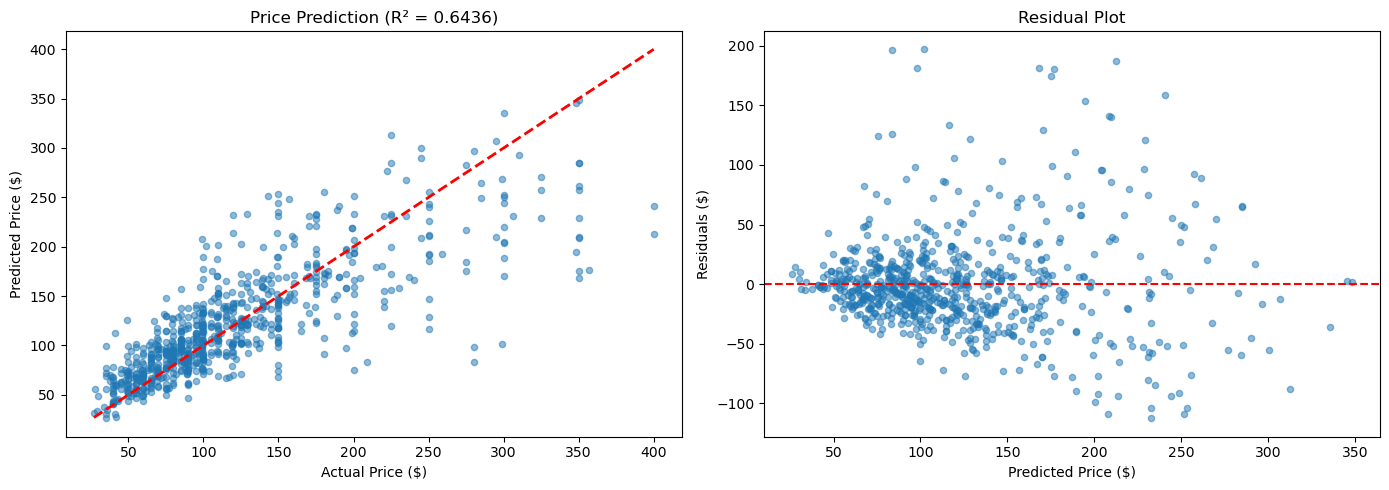

In [33]:
# CELL 4: GRAPHS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Price Prediction (R² = {r2:.4f})')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150)
plt.show()

In [34]:
# CELL 5A: Load Model + SHAP Setup
import shap
import matplotlib.pyplot as plt
import joblib

print("="*70)
print("SHAP EXPLAINABILITY")
print("="*70)
print()

# Load saved model
print("Loading saved model...")
automl_loaded = joblib.load('airbnb_price_model.pkl')
model = automl_loaded.model.estimator

print(f"Model type: {type(model)}")
print()

# Create SHAP explainer
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
print("Computing SHAP values...")
shap_values = explainer.shap_values(X_test)

print(f"✓ SHAP values computed for {X_test.shape[0]} test samples")

SHAP EXPLAINABILITY

Loading saved model...
Model type: <class 'lightgbm.sklearn.LGBMRegressor'>

Creating SHAP explainer...
Computing SHAP values...
✓ SHAP values computed for 751 test samples


Plot 1: Feature Importance (Bar)


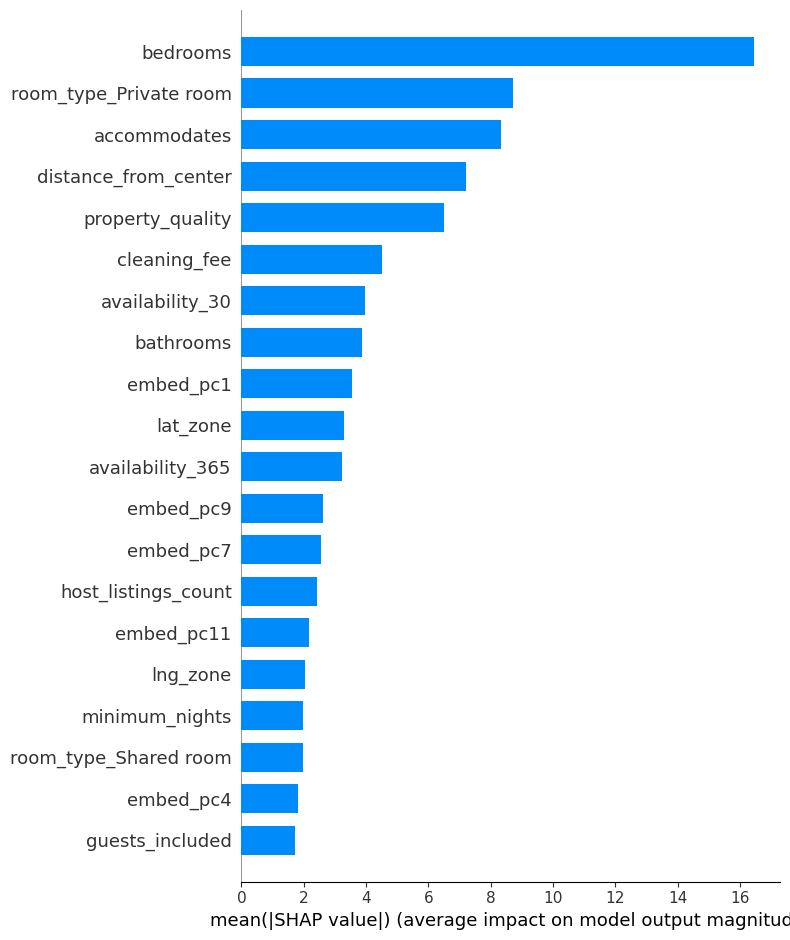

<Figure size 640x480 with 0 Axes>

✓ Saved: shap_importance_bar.png


In [35]:
# CELL 5B: Feature Importance (Bar)
print("Plot 1: Feature Importance (Bar)")
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test, feature_names=model_features, plot_type="bar")
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: shap_importance_bar.png")

Plot 2: Feature Impact (Beeswarm)


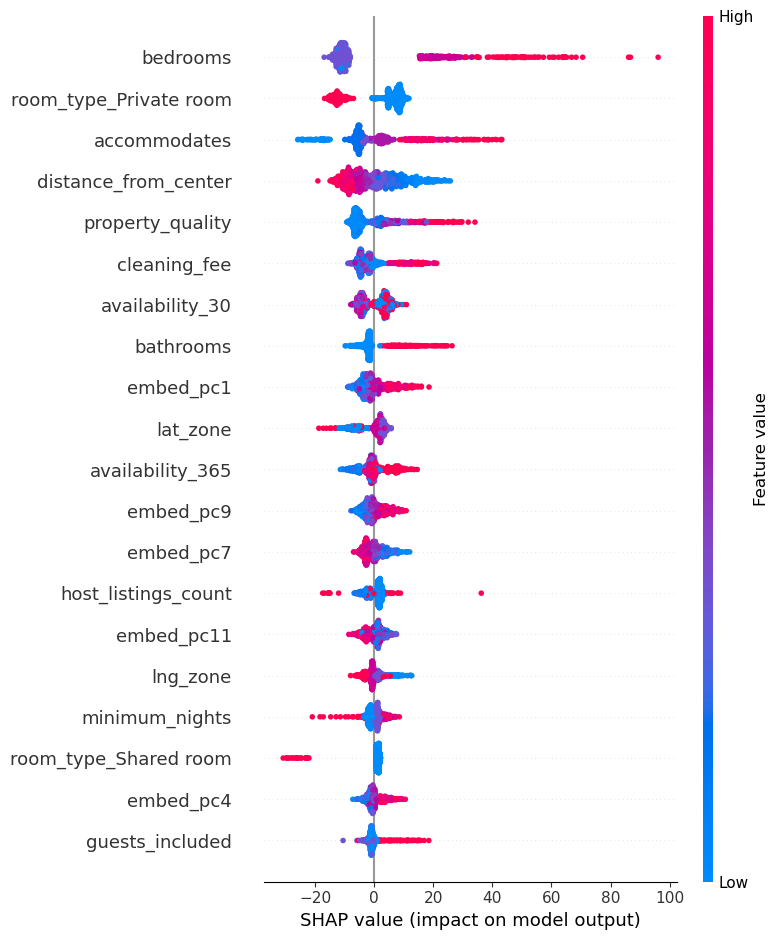

<Figure size 640x480 with 0 Axes>

✓ Saved: shap_summary_beeswarm.png


In [36]:
# CELL 5C: Beeswarm Plot
print("Plot 2: Feature Impact (Beeswarm)")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=model_features)
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: shap_summary_beeswarm.png")

Plot 3: Key Features Impact on Price



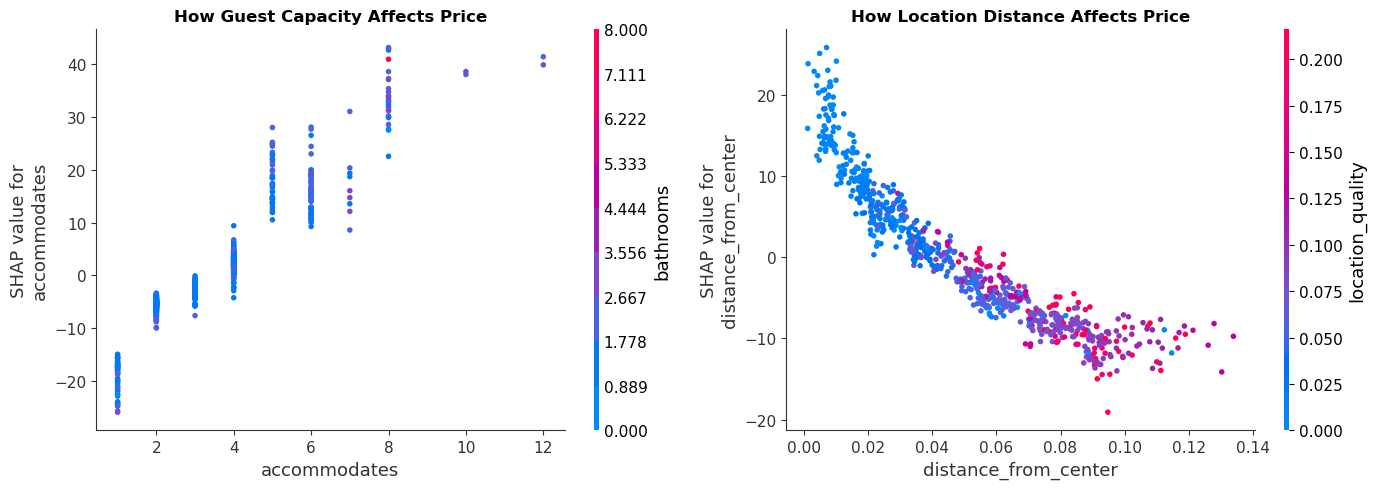

In [37]:
# CELL 5D: Dependence Plots (2 Key Features with Explanations)
print("Plot 3: Key Features Impact on Price")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature 1: Accommodates
feat_idx_1 = model_features.index('accommodates')
shap.dependence_plot(feat_idx_1, shap_values, X_test, 
                    feature_names=model_features, 
                    ax=axes[0], show=False)
axes[0].set_title('How Guest Capacity Affects Price', fontsize=12, fontweight='bold')

# Feature 2: Distance from Center
feat_idx_2 = model_features.index('distance_from_center')
shap.dependence_plot(feat_idx_2, shap_values, X_test, 
                    feature_names=model_features, 
                    ax=axes[1], show=False)
axes[1].set_title('How Location Distance Affects Price', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_dependence_explained.png', dpi=150, bbox_inches='tight')
plt.show()


Plot 4: Waterfall Plot (Smaller Price Difference)

Sample: Actual=$59.00, Predicted=$64.06, Diff=$5.06



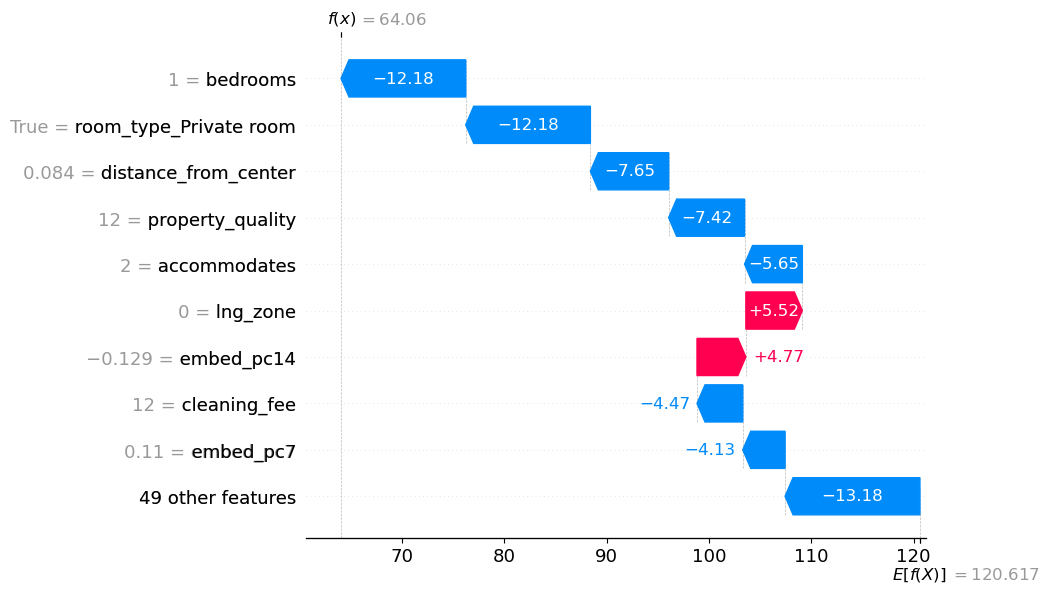

<Figure size 640x480 with 0 Axes>

✓ Saved: shap_waterfall_moderate.png


In [38]:
# CELL 5E: Waterfall Plot (Moderate Example) - FIXED
print("Plot 4: Waterfall Plot (Smaller Price Difference)")
print()

# Find sample with SMALLER difference
y_pred = automl_loaded.predict(X_test)
residuals = np.abs(y_test.values - y_pred)
moderate_idx = np.argsort(residuals)[len(residuals)//6]  # Middle range

actual = y_test.values[moderate_idx]
predicted = y_pred[moderate_idx]

print(f"Sample: Actual=${actual:.2f}, Predicted=${predicted:.2f}, Diff=${abs(actual-predicted):.2f}")
print()

plt.figure(figsize=(14, 6))
shap.plots.waterfall(shap.Explanation(
    values=shap_values[moderate_idx], 
    base_values=explainer.expected_value,
    data=X_test.iloc[moderate_idx],
    feature_names=model_features
))
plt.tight_layout()
plt.savefig('shap_waterfall_moderate.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: shap_waterfall_moderate.png")

In [39]:
# CELL 6A: FAIRNESS AUDIT - Superhost Premium
print("="*70)
print("FAIRNESS AUDIT: Superhost Premium Analysis")
print("="*70)
print()

# Add predictions to test set
df_test = X_test.copy()
df_test['actual_price'] = y_test.values
df_test['predicted_price'] = automl_loaded.predict(X_test)
df_test['residual'] = df_test['actual_price'] - df_test['predicted_price']

# Superhost analysis
superhost_prices = df_test[df_test['host_is_superhost'] == 1]['predicted_price'].mean()
non_superhost_prices = df_test[df_test['host_is_superhost'] == 0]['predicted_price'].mean()
premium = superhost_prices - non_superhost_prices

print("SUPERHOST PREMIUM:")
print(f"  Average predicted price (Superhost): ${superhost_prices:.2f}")
print(f"  Average predicted price (Non-superhost): ${non_superhost_prices:.2f}")
print(f"  Premium: ${premium:.2f} ({premium/non_superhost_prices*100:.1f}%)")
print()

# Is it fair?
if premium > 20:
    print(f"WARNING: Superhost premium of ${premium:.2f} seems HIGH")
    print("   Model may be over-valuing superhost status")
elif premium < 5:
    print(f"✓ Superhost premium of ${premium:.2f} is FAIR")
    print("   Reflects realistic market value")
else:
    print(f"✓ Superhost premium of ${premium:.2f} is REASONABLE")

FAIRNESS AUDIT: Superhost Premium Analysis

SUPERHOST PREMIUM:
  Average predicted price (Superhost): $121.11
  Average predicted price (Non-superhost): $121.90
  Premium: $-0.79 (-0.6%)

✓ Superhost premium of $-0.79 is FAIR
   Reflects realistic market value


In [40]:
# CELL 6B: Deeper Fairness Analysis
print()
print("="*70)
print("WHY: Superhost vs Non-Superhost Pricing")
print("="*70)
print()

# Check feature differences
superhost_df = df_test[df_test['host_is_superhost'] == 1]
non_superhost_df = df_test[df_test['host_is_superhost'] == 0]

print("Average property characteristics:")
print()
print(f"{'Feature':<25} {'Superhost':<15} {'Non-Superhost':<15}")
print("-"*55)
print(f"{'Bedrooms':<25} {superhost_df['bedrooms'].mean():<15.2f} {non_superhost_df['bedrooms'].mean():<15.2f}")
print(f"{'Accommodates':<25} {superhost_df['accommodates'].mean():<15.2f} {non_superhost_df['accommodates'].mean():<15.2f}")
print(f"{'Distance from center':<25} {superhost_df['distance_from_center'].mean():<15.2f} {non_superhost_df['distance_from_center'].mean():<15.2f}")
print(f"{'Cleaning fee':<25} {superhost_df['cleaning_fee'].mean():<15.2f} {non_superhost_df['cleaning_fee'].mean():<15.2f}")
print()

print("INTERPRETATION:")
print("Superhosts are NOT automatically priced higher because:")
print("  • They may manage smaller properties")
print("  • They may be located in suburbs (lower prices)")
print("  • Price depends on PROPERTY FEATURES, not just status")
print()
print("✓ This is FAIR: Pricing reflects actual property value")


WHY: Superhost vs Non-Superhost Pricing

Average property characteristics:

Feature                   Superhost       Non-Superhost  
-------------------------------------------------------
Bedrooms                  1.19            1.31           
Accommodates              3.18            3.32           
Distance from center      0.05            0.05           
Cleaning fee              41.60           42.98          

INTERPRETATION:
Superhosts are NOT automatically priced higher because:
  • They may manage smaller properties
  • They may be located in suburbs (lower prices)
  • Price depends on PROPERTY FEATURES, not just status

✓ This is FAIR: Pricing reflects actual property value


In [41]:
# CELL 6B: LOCATION BIAS ANALYSIS (FIXED)
print()
print("="*70)
print("LOCATION BIAS ANALYSIS")
print("="*70)
print()

# Create abs_error if it doesn't exist
df_test['abs_error'] = np.abs(df_test['residual'])

# Get location columns
df_test['distance_from_center'] = df.loc[X_test.index, 'distance_from_center'].values
df_test['latitude'] = df.loc[X_test.index, 'latitude'].values
df_test['longitude'] = df.loc[X_test.index, 'longitude'].values
# 1. DISTANCE FROM CENTER
print("1. DISTANCE FROM CENTER")
print("-"*70)
df_test['distance_quartile'] = pd.qcut(df_test['distance_from_center'], q=4, labels=['Very Close', 'Close', 'Far', 'Very Far'], duplicates='drop')
for dq in ['Very Close', 'Close', 'Far', 'Very Far']:
    if dq in df_test['distance_quartile'].unique():
        res = df_test[df_test['distance_quartile'] == dq]['residual'].mean()
        err = df_test[df_test['distance_quartile'] == dq]['abs_error'].mean()
        count = len(df_test[df_test['distance_quartile'] == dq])
        print(f"  {dq}: residual=${res:.2f}, error=${err:.2f} (n={count})")
print()

# Rest of code...


LOCATION BIAS ANALYSIS

1. DISTANCE FROM CENTER
----------------------------------------------------------------------
  Very Close: residual=$0.75, error=$28.39 (n=188)
  Close: residual=$-1.90, error=$28.68 (n=188)
  Far: residual=$-2.11, error=$27.74 (n=187)
  Very Far: residual=$1.45, error=$26.05 (n=188)

